# Предсказание следующего товара

#### Выполнил: Шарапов Артём Дмитриевич, студент 2 курса КНТ НИУ ВШ

### Часть 1: Анализ данных

In [5]:
import numpy as np

In [6]:
import json

sessions = []
with open("sessions.jsonl") as f:
    for line in f:
        line = line.strip()
        if line:
            sessions.append(json.loads(line))

# sessions — список списков целых чисел
print(f"Всего сессий: {len(sessions)}")
print(f"Первая сессия: {sessions[0]}")

Всего сессий: 2565
Первая сессия: [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341, 293]


In [ ]:
# число уникальных товаров

all_items = [item for session in sessions for item in session]
unique_items = set(all_items)
print(f"Число уникальных товаров: {len(unique_items)}")


Число уникальных товаров: 400


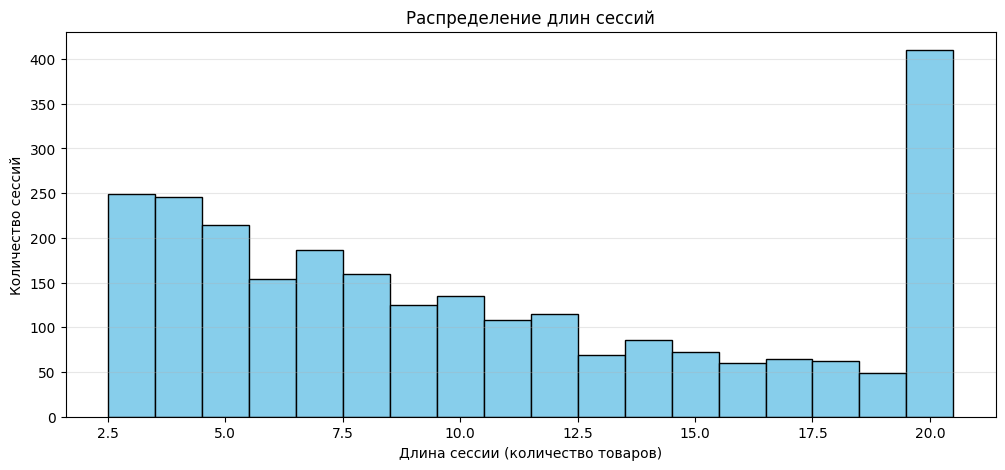

In [ ]:
import matplotlib.pyplot as plt

session_lengths = [len(s) for s in sessions]

plt.figure(figsize=(12, 5))
plt.hist(
    session_lengths,
    bins=range(min(session_lengths), max(session_lengths) + 2),
    color="skyblue",
    edgecolor="black",
    align="left",
)

plt.title("Распределение длин сессий")
plt.xlabel("Длина сессии")
plt.ylabel("Количество сессий")
plt.grid(axis="y", alpha=0.3)
plt.show()

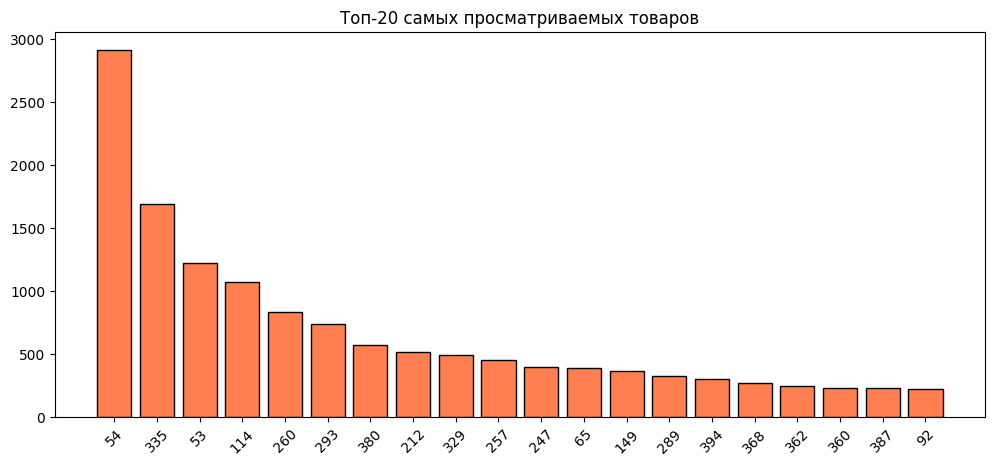

In [ ]:
from collections import Counter

most_popular = Counter(item for s in sessions for item in s).most_common(20)

plt.figure(figsize=(12, 5))
items, counts = zip(*most_popular)
plt.bar([str(i) for i in items], counts, color='coral', edgecolor='black')

plt.title('Топ-20 самых просматриваемых товаров')
plt.xticks(rotation=45)
plt.show()

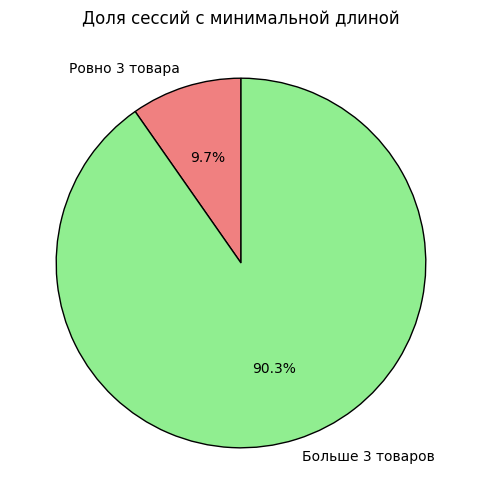

In [32]:
session_lengths = [len(s) for s in sessions]

len_3_count = sum(1 for length in session_lengths if length == 3)
len_more_count = len(sessions) - len_3_count

plt.figure(figsize=(6, 6))
plt.pie([len_3_count, len_more_count], 
        labels=['Ровно 3 товара', 'Больше 3 товаров'], 
        autopct='%1.1f%%', 
        colors=['lightcoral', 'lightgreen'], 
        startangle=90,
        wedgeprops={'edgecolor': 'black'})

plt.title('Доля сессий с минимальной длиной')
plt.show()

1. Коротких сессий больше, чем длинных. Но на длине сессии в 20 объявлений мы видим резкий скачок, скорее всего длинные сессии обрезаются по длине 20.
2. Товар 54 самый популярный, у него около 3000 просмотров. Это поможет рабоать бейзлайну довольно неплохо для рекомендации самых популярных товаров.
3. Сессий минимальной длины, которые имеют минимальный контекст и могут плохо повлиять на предсказание, всего 9.7 процентов, это хорошо.

### Часть 2: Train/test split

In [26]:
def train_test_split(
    sessions: list[list[int]],
) -> tuple[list[list[int]], list[int]]:
    """
    Разбиение сессий на train и test.

    Для каждой сессии:
      - все товары кроме последнего становятся
        обучающей сессией
      - последний товар становится тестовой целью

    Возвращаемые списки выровнены по индексу:
    test_targets[i] — товар, который нужно
    предсказать по train_sessions[i] как истории.

    Parameters
    ----------
    sessions : list of lists of ints
        Каждый вложенный список — одна сессия ID
        товаров, упорядоченная по времени.
        Все сессии содержат не менее 3 товаров.

    Returns
    -------
    train_sessions : list of lists of ints
        Сессии для обучения (исходные без последнего товара).
    test_targets : list of ints
        Следующий товар для предсказания по каждой сессии.
    """
    train_sessions = [session[:-1] for session in sessions]
    test_targets = [session[-1] for session in sessions]
    return train_sessions, test_targets

In [27]:
train_sessions, test_targets = train_test_split(sessions)

Данные имеют временный порядок, идут друг за другом. Случайное разбиение тут никак не подойдет, так как в трейне может оказаться товар, который находится в цепочке после того, что находится в тесте, это ломает весь смысл предсказания.

### Часть 3: Граф переходов

In [38]:
from collections import defaultdict

def build_graph(train_sessions: list[list[int]]) -> tuple[dict, list[int]]:
    transitions = defaultdict(Counter)
    item_freqs = Counter()

    # популярность товаров и переходы (рёбра)
    for session in train_sessions:
        item_freqs.update(session) 
        
        for u, v in zip(session[:-1], session[1:]):
            transitions[u][v] += 1

    graph = defaultdict(dict)
    
    # считаем вероятности p(v|u) и сортируем по убыванию
    for u, neighbors in transitions.items():
        total_transitions = sum(neighbors.values())
        
        probs = {v: count / total_transitions for v, count in neighbors.items()}
        graph[u] = dict(sorted(probs.items(), key=lambda x: x[1], reverse=True))

    top_items = [item for item, _ in item_freqs.most_common(20)]

    return dict(graph), top_items

graph, top_items = build_graph(train_sessions)

print(f"узлов в графе: {len(graph)}")

if 54 in graph:
    print("\nтоп-3 после товара 54:")
    for target, prob in list(graph[54].items())[:3]:
        print(f" -> {target}: {prob:.3f}")

узлов в графе: 400

топ-3 после товара 54:
 -> 53: 0.169
 -> 329: 0.087
 -> 335: 0.071


При построении графа мы считаем вероятности переходов между товарами P(j|i). Проблема в том, что не для каждого товара есть достаточное количество переходов. Поэтому заранее создаю список самых популярных товаров на основе train. 
Если последний товар из сессии вообще не встречался в обучении (то есть из него нет переходов в графе), мы не можем ничего предсказать по контексту.
В этом случае просто рекомендуем топ-10 самых популярных товаров. Если переходы есть, но их мало, берем их.
А недостающие позиции добиваем популярными товарами из global_popular, при этом не дублируем товары не рекомендуем тот товар, который пользователь только что смотрел

### Часть 4: Рекомендательная модель

In [41]:
def predict(session: list[int], graph: dict, top_items: list[int], k: int = 10) -> list[int]:
    u = session[-1] # последний товар
    recs = []
    seen = {u} # множество для быстрой проверки дублей (сразу исключаем текущий товар)
    
    # кандидаты из графа
    if u in graph:
        for v in graph[u]:
            if v not in seen:
                recs.append(v)
                seen.add(v)
            if len(recs) == k:
                return recs
                
    # добиваем популярными 
    for item in top_items:
        if item not in seen:
            recs.append(item)
            seen.add(item)
        if len(recs) == k:
            break
            
    return recs

# предсказания для всех тестовых сессий (train_sessions тут выступают как история)
preds = [predict(s, graph, top_items) for s in train_sessions]

print(f"Предсказания для первой сессии: {preds[0]}")
print(f"всего предсказаний: {len(preds)}")

Предсказания для первой сессии: [92, 149, 54, 287, 7, 212, 12, 260, 380, 335]
всего предсказаний: 2565


### Часть 5: Оценка качества

In [ ]:
def hit_at_k(
    recommendations: list[list[int]],
    true_items: list[int],
    k: int = 10,
) -> float:
    """
    Вычисление Hit@K для списка предсказаний.

    Parameters
    ----------
    recommendations : list of lists of ints
        recommendations[i] — ранжированный список
        рекомендаций для i-го примера.
    true_items : list of ints
        true_items[i] — истинный следующий товар
        для i-го примера.
    k : int
        Отсечка top-K (по умолчанию 10).

    Returns
    -------
    float
        Hit@K, значение от 0 до 1.
    """
    assert len(recommendations) == len(true_items), (
        "recommendations и true_items должны совпадать по длине"
    )

    hits = 0
    for recs, true_item in zip(recommendations, true_items):
        if true_item in recs[:k]:
            hits += 1

    return hits / len(true_items)

In [ ]:
# метрика для графовой модели
model_hit = hit_at_k(preds, test_targets, k=10)

# просто топ популярных для каждой сессии
baseline_preds = []
for s in train_sessions:
    u = s[-1]
    recs = [item for item in top_items if item != u][:10]
    baseline_preds.append(recs)

baseline_hit = hit_at_k(baseline_preds, test_targets, k=10)

print(f"hit@10 (graph): {model_hit:.4f}")
print(f"hit@10 (popularity): {baseline_hit:.4f}")
print(f"прирост: {(model_hit / baseline_hit - 1) * 100:.2f}%")

hit@10 (graph): 0.5142
hit@10 (popularity): 0.3879
прирост: 32.56%


В рамках работы я реализовал рекомендательную систему на основе цепей Маркова первого порядка.
По ходу анализа данных стало понятно, что есть явные товары-хиты, которые сильно выбиваются по популярности и что длина сессий, скорее всего, искусственно ограничена 20 товарами.

Дальше провёл тестирование модели. Граф переходов показал Hit@10 = 0.5142, тогда как простой бейзлайн на популярности даёт 0.3879. Это примерно на 32.5% лучше.
Такой прирост говорит о том, что поведение пользователей здесь не случайное, а следующий товар действительно сильно зависит от текущего. В итоге модель нормально справляется с персонализацией внутри сессии и обгоняет базовый подход.